In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Section 1: Loading data and validation

In [8]:
path = '/Users/kaungkhantkyaw/Documents/GitHub/Analyse-US-Domestic-flights/Data/Cleaned/DB1B_Market_model_ready.parquet'
df_model = pd.read_parquet(path)

print(df_model.shape)
display(df_model.head())
display(df_model.sample(5, random_state = 42))
display(df_model.info())

(7189747, 15)


,Origin,Dest,OriginState,DestState,TkCarrier,Passengers,MktDistance,MktCoupons,MktDistanceGroup,MktGeoType,extra_miles,carrier_mismatch,log_passengers,distance_per_coupon,MktFare
0,SAN,ATL,CA,GA,DL,1.0,1892.0,1,4,2,0.0,0,0.693147,1892.0,351.5
1,ATL,SAN,GA,CA,DL,2.0,1892.0,1,4,2,0.0,0,1.098612,1892.0,352.0
2,SAN,ATL,CA,GA,DL,2.0,1892.0,1,4,2,0.0,0,1.098612,1892.0,352.0
3,ATL,SAN,GA,CA,DL,1.0,1892.0,1,4,2,0.0,0,0.693147,1892.0,352.5
4,SAN,ATL,CA,GA,DL,1.0,1892.0,1,4,2,0.0,0,0.693147,1892.0,352.5


,Origin,Dest,OriginState,DestState,TkCarrier,Passengers,MktDistance,MktCoupons,MktDistanceGroup,MktGeoType,extra_miles,carrier_mismatch,log_passengers,distance_per_coupon,MktFare
1799499,GRR,AUS,MI,TX,DL,1.0,1269.0,2,3,2,166.0,1,0.693147,634.5,5.13
7057535,HSV,RDU,AL,NC,DL,1.0,507.0,2,2,2,47.0,0,0.693147,253.5,307.00
4843690,ORD,DEN,IL,CO,WN,1.0,888.0,1,2,2,0.0,0,0.693147,888.0,210.00
6002858,MCO,GJT,FL,CO,UA,1.0,1758.0,2,4,2,36.0,0,0.693147,879.0,522.00
878153,BIL,BFL,MT,CA,AA,1.0,1298.0,2,3,2,395.0,1,0.693147,649.0,194.00


<class 'pandas.DataFrame'>
RangeIndex: 7189747 entries, 0 to 7189746
Data columns (total 15 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Origin               str    
 1   Dest                 str    
 2   OriginState          str    
 3   DestState            str    
 4   TkCarrier            str    
 5   Passengers           float64
 6   MktDistance          float64
 7   MktCoupons           int64  
 8   MktDistanceGroup     int64  
 9   MktGeoType           int64  
 10  extra_miles          float64
 11  carrier_mismatch     int64  
 12  log_passengers       float64
 13  distance_per_coupon  float64
 14  MktFare              float64
dtypes: float64(6), int64(4), str(5)
memory usage: 905.1 MB


None

Section 2: Sample & Separate

Theres almost 7.2 million rows, thus sampling is needed to prevent long training times and using alot of memory.
The sample dataset is also compared to the full set to ensure consistentcy in values.


In [11]:
sample_size = 100_000
target = 'MktFare'

if len(df_model) > sample_size:
    df_sample = df_model.sample(sample_size, random_state = 42).copy()
else:
    df_sample = df_model.copy()

In [12]:
sample_comparison = pd.DataFrame({
    'full_dataset': df_model['MktFare'].describe(),
    'sampled_dataset': df_sample['MktFare'].describe()
})

display(sample_comparison)

quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

sample_comparison_quantiles = pd.DataFrame({
    'full_dataset': df_model['MktFare'].quantile(quantiles),
    'sampled_dataset': df_sample['MktFare'].quantile(quantiles)
})

display(sample_comparison_quantiles)


,full_dataset,sampled_dataset
count,7.189747e+06,100000.000000
mean,2.641319e+02,264.463935
std,1.741388e+02,174.320416
min,5.000000e+00,5.000000
25%,1.500000e+02,150.710000
50%,2.331700e+02,233.285000
75%,3.435000e+02,343.500000
max,1.142000e+03,1142.000000


,full_dataset,sampled_dataset
0.01,5.000,5.000
0.05,25.313,25.000
0.25,150.000,150.710
0.50,233.170,233.285
0.75,343.500,343.500
0.95,591.500,593.000
0.99,883.500,884.000


In [14]:
x = df_sample.drop(columns = [target]).copy()
y = df_sample[target].copy()

print("Is target included in x: ", target in x.columns)
print("Features shape: ", x.shape)
print("Target shape: ", y.shape)
print("Target median: ", y.median())

Is target included in x:  False
Features shape:  (100000, 14)
Target shape:  (100000,)
Target median:  233.285


Section 3: Train/Test split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
#x_train is used to train the model, y_train provides the fare values corresponding to it. x_test is the
#unseen values used to test the model, y_test provides the actual fares used to check test predictions.
#80% training data, 20% test data split

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)


x_train shape:  (80000, 14)
x_test shape:  (20000, 14)
y_train shape:  (80000,)
y_test shape:  (20000,)


In [ ]:
cat_cols = ['Origin', 'Dest', 'OriginState', 'DestState', 'TkCarrier', 
'MktDistanceGroup', 'MktGeoType', 'carrier_mismatch']

num_cols = ['Passengers', 'MktDistance', 'MktCoupons', 'extra_miles', 'log_passengers', 'distance_per_coupon']

selected_cols = cat_cols + num_cols

print('Number of selected features: ', len(selected_cols))
print('Number of x columns: ', x.shape[1])

Number of selected features:  14
Number of x columns:  14


In [21]:
cat_transformer = OneHotEncoder(handle_unknown = 'ignore') #handle_unknown = 'ignore' is used to ignore situations where a rare unseen category appears in test, letting the code run
num_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers = 
[('categorical', cat_transformer, cat_cols), ('numeric', num_transformer, num_cols)], remainder = 'drop')
display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

Section 4: Baseline and Regression model

In [23]:
dummy_model = DummyRegressor(strategy = 'median') #the model predicts the same median fare for every row, median used as more robust
dummy_model.fit(x_train, y_train)
dummy_pred = dummy_model.predict(x_test)

display(dummy_pred[:10])


array([233.01, 233.01, 233.01, 233.01, 233.01, 233.01, 233.01, 233.01,
       233.01, 233.01])

In [24]:
dummy_mae = mean_absolute_error(y_test, dummy_pred)
#average abs difference between predicted and actual fares
dummy_rmse = mean_squared_error(y_test, dummy_pred)**0.5
#Provides large errors more influences, making detecting them easier
dummy_r2 = r2_score(y_test, dummy_pred)


In [25]:
def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    r2 = r2_score(y_true, y_pred)

    return{'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [26]:
dummy_results = evaluate_regression_model(model_name = 'Dummy Median', y_true = y_test, y_pred = dummy_pred)
display(dummy_results)

model_results = []
model_results.append(dummy_results)


{'Model': 'Dummy Median',
 'MAE': 126.096694,
 'RMSE': 176.96874842553416,
 'R2': -0.03271356183254248}

In [27]:
linear_pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('model', LinearRegression())])

linear_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [28]:
linear_pred = linear_pipeline.predict(x_test)
display(linear_pred.shape)
display(linear_pred[:10])

(20000,)

array([308.14781557, 348.14418393, 115.87278461, 174.92030863,
       264.26363501, 200.28241685, 222.96357475, 270.47391141,
       264.0352995 , 299.13004647])

In [ ]:
display((linear_pred < 0).sum())
#negative predictions are not realistic

np.int64(65)

In [ ]:
linear_results = evaluate_regression_model(model_name = 'Linear Regression', y_true = y_test, y_pred = linear_pred)
display(linear_results)

model_results.append(linear_results)
results_df = pd.DataFrame(model_results)
display(results_df)

{'Model': 'Linear Regression',
 'MAE': 111.6290228941815,
 'RMSE': 155.3474866709794,
 'R2': 0.20421603473457217}

,Model,MAE,RMSE,R2
0,Dummy Median,126.096694,176.968748,-0.032714
1,Linear Regression,111.629023,155.347487,0.204216


In [40]:
mae_improvement = (((dummy_results['MAE'] - linear_results['MAE']) / dummy_results['MAE']) * 100)
print(f"MAE improvement over baseline/dummy model: {mae_improvement:.2f}%")

MAE improvement over baseline/dummy model: 11.47%


Linear regression performed better than the dummy baseline, reducing MAE and RMSE. The R2 value of approximately 0.20 shows that it only explains 20% of the market fare varaitions, which concludes that the relationship between features and fares are more complex and non-linear

In [ ]:
#initial row by row residual analysis by comparing actual and predicted fares
prediction_comparison = pd.DataFrame({
    'ActualFare': y_test.to_numpy(),
    'PredictedFare': linear_pred
})
display(prediction_comparison.head(10))
#this shows how accurate the model was for each individual itinerary record

prediction_comparison['Residual'] = (prediction_comparison['ActualFare'] - prediction_comparison['PredictedFare'])
prediction_comparison['AbsoluteResidual'] = prediction_comparison['Residual'].abs()
display(prediction_comparison.head(10))
#positive residual means underpredict, negative residual means overpredict, near 0 means accurate

,ActualFare,PredictedFare
0,300.50,308.147816
1,143.50,348.144184
2,67.50,115.872785
3,138.00,174.920309
4,122.50,264.263635
5,113.50,200.282417
6,217.00,222.963575
7,5.75,270.473911
8,500.96,264.035300
9,836.00,299.130046


,ActualFare,PredictedFare,Residual,AbsoluteResidual
0,300.50,308.147816,-7.647816,7.647816
1,143.50,348.144184,-204.644184,204.644184
2,67.50,115.872785,-48.372785,48.372785
3,138.00,174.920309,-36.920309,36.920309
4,122.50,264.263635,-141.763635,141.763635
5,113.50,200.282417,-86.782417,86.782417
6,217.00,222.963575,-5.963575,5.963575
7,5.75,270.473911,-264.723911,264.723911
8,500.96,264.035300,236.924700,236.924700
9,836.00,299.130046,536.869954,536.869954


even though this is only 10 rows, we can see that lower fares tend to be overpredicted and very high fares are underpredicted, with the linear regression model learning to predict closer to the centre of the target distribution and struggling with more extreme/complex values

Section 5: Tree-based Model

In [33]:
tree_preprocessor = ColumnTransformer(transformers = [('categorical', OneHotEncoder(handle_unknown = 'ignore'), cat_cols), 
('numeric', 'passthrough', num_cols)], remainder = 'drop')

random_forest_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20,
    min_samples_leaf = 2,
    random_state = 42,
    n_jobs = -1
)

random_forest_pipeline = Pipeline(
    steps = [('preprocessor', tree_preprocessor), ('model', random_forest_model)]
)
random_forest_pipeline.fit(x_train, y_train)

Python(61542) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [35]:
random_forest_pred = random_forest_pipeline.predict(x_test)
display(random_forest_pred.shape)
display(random_forest_pred[:10])
display((random_forest_pred < 0).sum())

(20000,)

array([275.45097629, 345.0503302 ,  85.77979314, 147.42229158,
       286.8599173 , 184.15180199, 229.72082298, 245.2927616 ,
       245.23222833, 297.89875373])

np.int64(0)

In [36]:
random_forest_results = evaluate_regression_model(model_name = 'Random Forest', y_true = y_test, y_pred = random_forest_pred)
display(random_forest_results)

model_results.append(random_forest_results)
results_df = pd.DataFrame(model_results)
display(results_df)

{'Model': 'Random Forest',
 'MAE': 110.16881543430972,
 'RMSE': 154.2985994425306,
 'R2': 0.21492582864473742}

,Model,MAE,RMSE,R2
0,Dummy Median,126.096694,176.968748,-0.032714
1,Linear Regression,111.629023,155.347487,0.204216
2,Random Forest,110.168815,154.298599,0.214926


In [41]:
rf_mae_improvement = (
    ((linear_results['MAE'] - random_forest_results['MAE']) / linear_results['MAE']) * 100
)
print(f"Random Forest MAE improvement over Linear Regression: {rf_mae_improvement:.2f}%")

Random Forest MAE improvement over Linear Regression: 1.31%


In [43]:
prediction_distribution_comparison = pd.DataFrame({
    'ActualFare': y_test.describe(),
    'LinearPrediction': pd.Series(linear_pred).describe(),
    'RandomForestPrediction': pd.Series(random_forest_pred).describe()
})
display(prediction_distribution_comparison)
#this shows if each model has a similar distribution of predictions compared to actual fares

,ActualFare,LinearPrediction,RandomForestPrediction
count,20000.000000,20000.000000,20000.000000
mean,264.507099,265.050435,264.784039
std,174.147601,82.361177,85.136746
min,5.000000,-87.378230,10.031467
25%,150.500000,225.221176,216.424908
50%,233.500000,274.733782,265.251720
75%,343.832500,316.027761,316.859405
max,1139.000000,1043.697980,745.640715


In [45]:
rf_pred_comparison = pd.DataFrame({
    'ActualFare': y_test.to_numpy(),
    'PredictedFare': random_forest_pred
})
display(rf_pred_comparison.head(10))

#residual analysis
rf_pred_comparison['Residual'] = (rf_pred_comparison['ActualFare'] - rf_pred_comparison['PredictedFare'])
rf_pred_comparison['AbsoluteResidual'] = rf_pred_comparison['Residual'].abs()
display(rf_pred_comparison.head(10))

,ActualFare,PredictedFare
0,300.50,275.450976
1,143.50,345.050330
2,67.50,85.779793
3,138.00,147.422292
4,122.50,286.859917
5,113.50,184.151802
6,217.00,229.720823
7,5.75,245.292762
8,500.96,245.232228
9,836.00,297.898754


,ActualFare,PredictedFare,Residual,AbsoluteResidual
0,300.50,275.450976,25.049024,25.049024
1,143.50,345.050330,-201.550330,201.550330
2,67.50,85.779793,-18.279793,18.279793
3,138.00,147.422292,-9.422292,9.422292
4,122.50,286.859917,-164.359917,164.359917
5,113.50,184.151802,-70.651802,70.651802
6,217.00,229.720823,-12.720823,12.720823
7,5.75,245.292762,-239.542762,239.542762
8,500.96,245.232228,255.727772,255.727772
9,836.00,297.898754,538.101246,538.101246


In [ ]:
model_prediction_comparison = pd.DataFrame({
    'ActualFare': y_test.to_numpy(),
    'LinearPrediction': linear_pred,
    'RandomForestPrediction': random_forest_pred
})

model_prediction_comparison['LinearAbsoluteError'] = (model_prediction_comparison['ActualFare'] - model_prediction_comparison['LinearPrediction']).abs()
model_prediction_comparison['RandomForestAbsoluteError'] = (model_prediction_comparison['ActualFare'] - model_prediction_comparison['RandomForestPrediction']).abs()
display(model_prediction_comparison.head(10))

#this table enables us to see if random forest improves on the linear regression model



,ActualFare,LinearPrediction,RandomForestPrediction,LinearAbsoluteError,RandomForestAbsoluteError
0,300.50,308.147816,275.450976,7.647816,25.049024
1,143.50,348.144184,345.050330,204.644184,201.550330
2,67.50,115.872785,85.779793,48.372785,18.279793
3,138.00,174.920309,147.422292,36.920309,9.422292
4,122.50,264.263635,286.859917,141.763635,164.359917
5,113.50,200.282417,184.151802,86.782417,70.651802
6,217.00,222.963575,229.720823,5.963575,12.720823
7,5.75,270.473911,245.292762,264.723911,239.542762
8,500.96,264.035300,245.232228,236.924700,255.727772
9,836.00,299.130046,297.898754,536.869954,538.101246


In [47]:
random_forest_train_pred = random_forest_pipeline.predict(x_train)
random_forest_train_results = evaluate_regression_model(
    model_name = 'Random Forest (Training)',
    y_true = y_train,
    y_pred = random_forest_train_pred
    )

display(pd.DataFrame([random_forest_results, random_forest_train_results]))

,Model,MAE,RMSE,R2
0,Random Forest,110.168815,154.298599,0.214926
1,Random Forest (Training),100.437133,140.049238,0.354866


Random forest edges over linear regression just slightly, reductions in MAE and increment in R2 is observed. This suggests that random forest only captured minimal non linear structure.

According to the distribution, both models are able to hit the mean but still pull towards the middle due to their standard deviations. Random forest max is only $745.64, this is quite far from the actual's max of $1139, suggesting its strugges with expensive records and tends to underpredict it.

There is a slight overfitting but its very minimal, this might suggest that there is limited predictive information too.

Section 6: Residual Analysis and Feature Importance

In [ ]:
rf_residual = x_test.reset_index(drop = True).copy()
rf_residual['ActualFare'] = y_test.reset_index(drop = True)
rf_residual['PredictedFare'] = random_forest_pred
rf_residual['Residual'] = (rf_residual['ActualFare'] - rf_residual['PredictedFare'])
rf_residual['AbsoluteResidual'] = rf_residual['Residual'].abs()
display(rf_residual.head())
#another residual dataframe is set up as the previous in section 5 did not contain features

,Origin,Dest,OriginState,DestState,TkCarrier,Passengers,MktDistance,MktCoupons,MktDistanceGroup,MktGeoType,extra_miles,carrier_mismatch,log_passengers,distance_per_coupon,ActualFare,PredictedFare,Residual,AbsoluteResidual
0,MSY,ATL,LA,GA,DL,1.0,425.0,1,1,2,0.0,0,0.693147,425.0,300.5,275.450976,25.049024,25.049024
1,ILM,PHX,NC,AZ,DL,1.0,1964.0,2,4,2,11.0,1,0.693147,982.0,143.5,345.050330,-201.550330,201.550330
2,ATL,MCO,GA,FL,NK,1.0,404.0,1,1,2,0.0,0,0.693147,404.0,67.5,85.779793,-18.279793,18.279793
3,SFO,PSP,CA,CA,AS,3.0,421.0,1,1,2,0.0,1,1.386294,421.0,138.0,147.422292,-9.422292,9.422292
4,ROC,CHS,NY,SC,DL,1.0,1008.0,2,3,2,291.0,0,0.693147,504.0,122.5,286.859917,-164.359917,164.359917


In [54]:
display(rf_residual[['Residual', 'AbsoluteResidual']].describe())
display(rf_residual['Residual'].median())

over_under_prediction_count = pd.Series({
    'Underpredict': (
        rf_residual['Residual'] > 0
    ).sum(),
    'Overpredict':(
        rf_residual['Residual'] < 0
    ).sum(),
    'Exact predict':(
        rf_residual['Residual'] == 0
    ).sum()
})
display(over_under_prediction_count)

,Residual,AbsoluteResidual
count,20000.000000,20000.000000
mean,-0.276940,110.168815
std,154.302209,108.034594
min,-574.084322,0.001604
25%,-88.894123,37.034457
50%,-19.691699,80.265337
75%,66.224092,145.877101
max,907.887520,907.887520


np.float64(-19.69169910326852)

Underpredict      8569
Overpredict      11431
Exact predict        0
dtype: int64

we can see that a negative mean residule is visibile, this can be intepreted as overprediction occuring on average

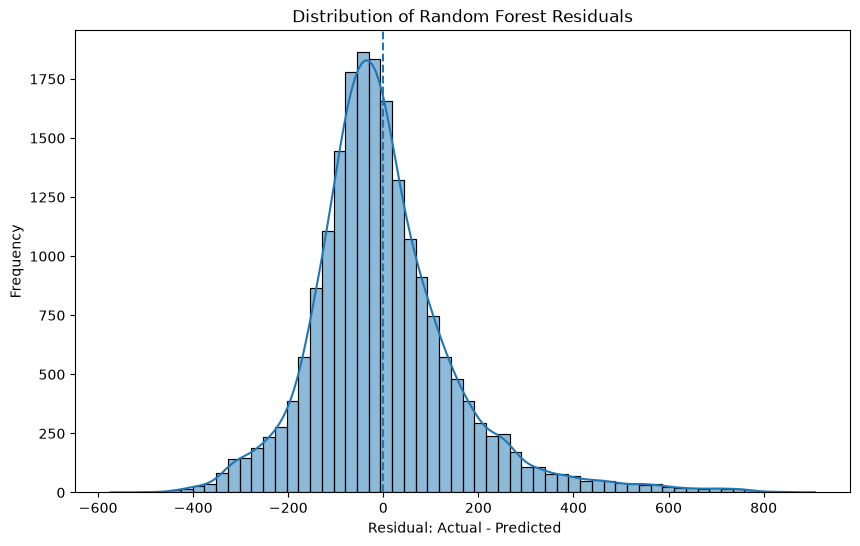

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(rf_residual, x = 'Residual', bins= 60, kde = True) #kde provides a line that helps to see the shape better
plt.axvline(0, linestyle = '--') #this provides a vertical line at 0, which represents the exact value, any other value is over or under predicted
plt.title('Distribution of Random Forest Residuals')
plt.xlabel(' Residual: Actual - Predicted')
plt.ylabel('Frequency')
plt.show()


From this histogram, we can see that most of the values are grouped around 0, mainly under the +-200 residual mark. A long positive tail is observed, telling us that expensive fares are underpredicted.

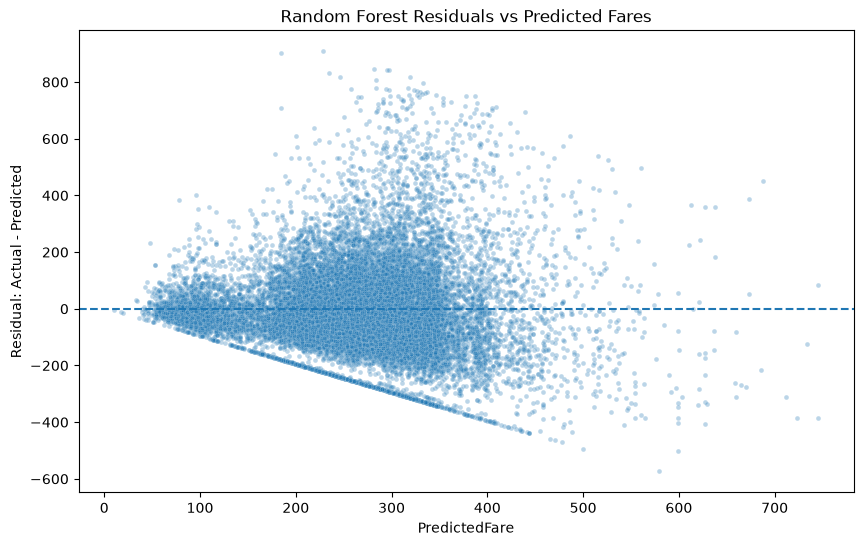

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = rf_residual, x = 'PredictedFare', y = 'Residual', s = 12, alpha = 0.3)
plt.axhline(0, linestyle = '--')
plt.title('Random Forest Residuals vs Predicted Fares')
plt.ylabel('Residual: Actual - Predicted')
plt.show()

#this scatter plot checks if error behaviour changes based on predicted fare

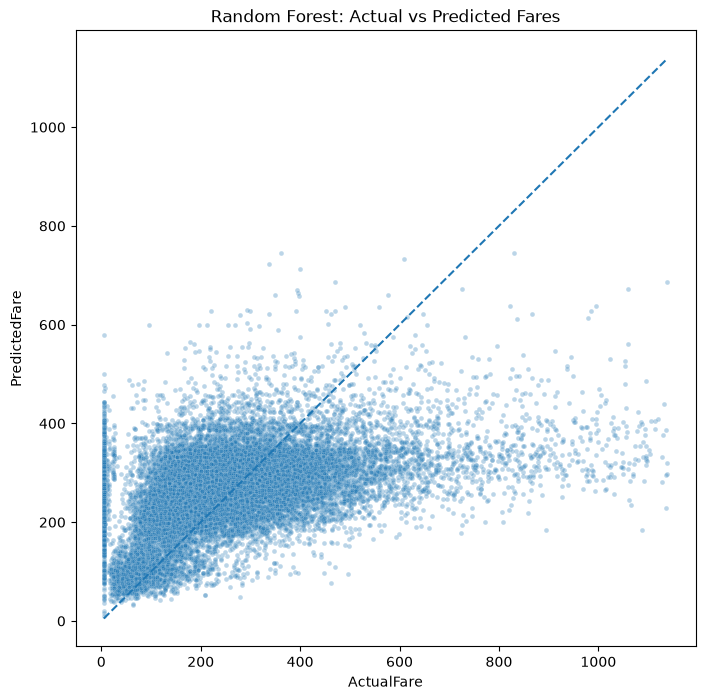

In [62]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data = rf_residual, x = 'ActualFare', y = 'PredictedFare', s = 12, alpha = 0.3)
min_value = min(rf_residual['ActualFare'].min(), rf_residual['PredictedFare'].min())
max_value = max(rf_residual['ActualFare'].max(), rf_residual['PredictedFare'].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle = '--')
plt.title('Random Forest: Actual vs Predicted Fares')
plt.show()


When comparing Actual Fare vs Predicted Fare, we can see that the majority of predicted fares are above the line when actual fare is low, this can be seen as overprediction. As actual fare gets into the higher teritory, most points are now below the line, which is seen as an underprediction.

In [63]:
fare_bins = [0, 100, 200, 300, 500, np.inf] #np.inf means positive infinity, so above 500

fare_labels = [
    '$0-$100',
    '$100-$200',
    '$200-$300',
    '$300-$500',
    '$500+'
]

rf_residual['FareBand'] = pd.cut(rf_residual['ActualFare'], bins = fare_bins, labels = fare_labels, right = False) 
#'right = false' means values on the left side of the bin is included
error_by_fare_band = rf_residual.groupby('FareBand', observed = True).agg(
    Records = ('ActualFare', 'size'),
    MeanActualFare = ('ActualFare', 'mean'),
    MeanPredictedFare = ('PredictedFare', 'mean'),
    MeanResidual = ('Residual', 'mean'),
    MAE = ('AbsoluteResidual', 'mean')
).reset_index() #'observed = True' means only bins that have values will appear, if there is no value in >500, the bin wont appear
display(error_by_fare_band)


,FareBand,Records,MeanActualFare,MeanPredictedFare,MeanResidual,MAE
0,$0-$100,2708,47.667242,187.108599,-139.441357,140.626351
1,$100-$200,5233,154.655603,238.118508,-83.462905,92.068708
2,$200-$300,5392,246.487396,274.275749,-27.788353,56.780495
3,$300-$500,4965,378.880109,299.430373,79.449736,94.518423
4,$500+,1702,670.708895,339.218504,331.490391,332.150529


In [64]:
#Feature importance
fitted_preprocessor = random_forest_pipeline.named_steps['preprocessor']
fitted_rf_model = random_forest_pipeline.named_steps['model']
#named_steps is used to access the preprocessor and model objects in the pipeline

transformed_feature_names = fitted_preprocessor.get_feature_names_out()#this helps to get the names of the cateogrical columns that were transformed
feature_importance_values = fitted_rf_model.feature_importances_ #this accesses the importance score for every input column when the RF is trained

feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': feature_importance_values
})

,OriginalFeature,Importance
0,TkCarrier,0.265088
1,MktDistance,0.197070
2,distance_per_coupon,0.106756
3,Dest,0.086385
4,Origin,0.085710
5,log_passengers,0.058209
6,Passengers,0.048383
7,DestState,0.043750
8,extra_miles,0.042251
9,OriginState,0.042193


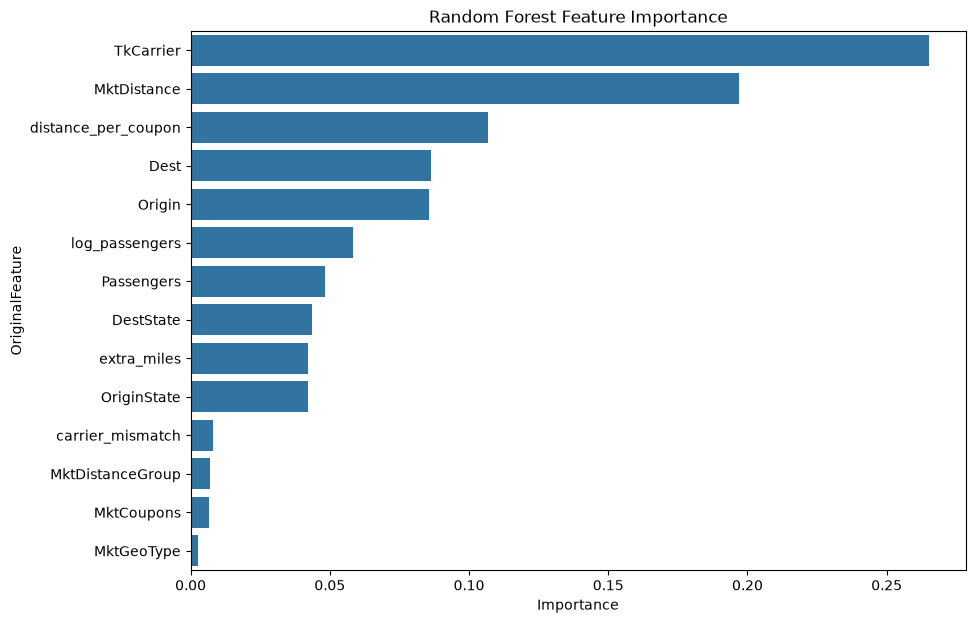

In [67]:
#this transforms the names back to original feautre names
def get_original_feature_name(feature_name):
    clean_name = feature_name.split('__', 1)[-1] #this makes a name like 'cat__Origin_JFK' into 'Origin_JFK' by splitting at the double underscore and selected the last part[-1]

    for column in cat_cols:
        if clean_name.startswith(f"{column}_"): #this checks if the cleaned name starts with the original column name and returns as original name
            return column
    
    if clean_name in num_cols: #no one-hot done for numeric so it just needs to take out 'numeric__'
        return clean_name
    
    return clean_name

feature_importance_df['OriginalFeature'] = feature_importance_df['Feature'].apply(get_original_feature_name) #.apply runs the function once for every value in the feature column
grouped_feature_importance = feature_importance_df.groupby('OriginalFeature', as_index = False)['Importance'].sum().sort_values('Importance', ascending = False).reset_index(drop = True)
#this helps to combine all the scores into one singular original feature name, it groups by the name and sums it up. Important for one-hot as it is split across many dummy columns
display(grouped_feature_importance)

plt.figure(figsize = (10, 7))
sns.barplot( data = grouped_feature_importance, x = 'Importance', y = 'OriginalFeature')
plt.title('Random Forest Feature Importance')
plt.show()

We can see that TkCarrier had the most influence, followed by MktDistance. The importance of the rest drops considerably.

*This section was pretty new to me, residual analysis was easier to understand the concept and the code. Feature importance was slightly more foreign, especially since i had to convert from one-hot back to normal feature